<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/small_mass_hanging_motion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Radial Oscillations vs Rotational Motion of $m$ under small oscillations of $m_{2}$

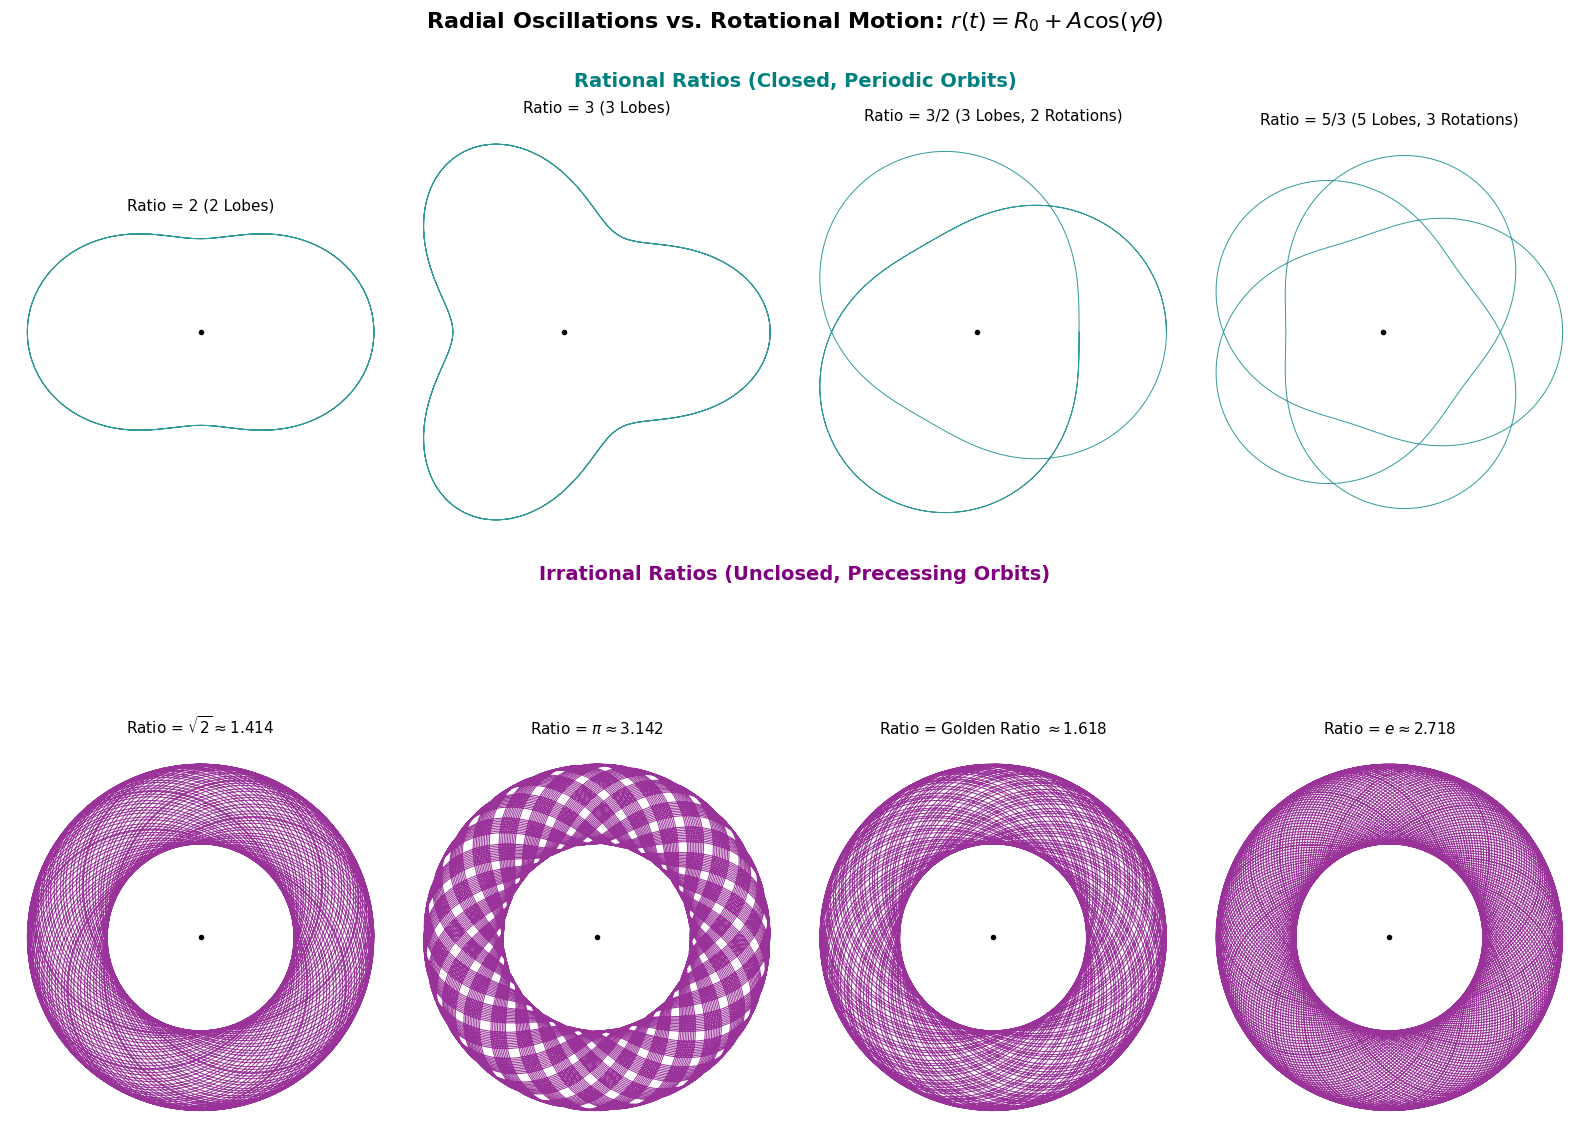

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. System Parameters
# ==========================================
r0 = 10.0      # Equilibrium radius
A = 3.0        # Amplitude of the radial oscillation
phi = 0.0      # Initial phase shift

# We define the ratio of frequencies: gamma = w_osc / w_rot
# If we normalize time such that w_rot = 1, then theta(t) = t, and w_osc = gamma.
# The radial equation becomes: r(t) = r0 + A * cos(gamma * t + phi)

# ==========================================
# 2. Define Frequency Ratios
# ==========================================
# Rational ratios will produce perfectly closed "flower" orbits.
rational_ratios = [
    (2.0, "2 (2 Lobes)"),
    (3.0, "3 (3 Lobes)"),
    (1.5, "3/2 (3 Lobes, 2 Rotations)"),
    (5/3, "5/3 (5 Lobes, 3 Rotations)")
]

# Irrational ratios will produce unclosed "spirograph" orbits that endlessly precess.
irrational_ratios = [
    (np.sqrt(2), r"$\sqrt{2} \approx 1.414$"),
    (np.pi, r"$\pi \approx 3.142$"),
    ((1 + np.sqrt(5))/2, r"Golden Ratio $\approx 1.618$"),
    (np.e, r"$e \approx 2.718$")
]

# ==========================================
# 3. Plotting Function
# ==========================================
def plot_orbit(ax, gamma, title, is_rational):
    """
    Generates and plots the x, y coordinates for the given frequency ratio.
    """
    # For rational (closed) orbits, we only need a few rotations to complete the shape.
    # For irrational (unclosed) orbits, we simulate for much longer to show the dense filling.
    t_max = 6 * np.pi if is_rational else 150 * np.pi
    t = np.linspace(0, t_max, 10000)

    # Calculate radial distance and angle over time
    theta = t  # Normalized rotation (w_rot = 1)
    r = r0 + A * np.cos(gamma * t + phi)

    # Convert polar to Cartesian coordinates
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Plot the trajectory
    color = 'teal' if is_rational else 'purple'
    ax.plot(x, y, color=color, linewidth=0.7, alpha=0.8)

    # Plot the central hole for reference
    ax.plot(0, 0, 'ko', markersize=3)

    # Formatting
    ax.set_title(f"Ratio = {title}", fontsize=11, pad=10)
    ax.set_aspect('equal')
    ax.axis('off')  # Hide grid and axes for a cleaner look

# ==========================================
# 4. Generate the Figure
# ==========================================
if __name__ == "__main__":
    fig, axes = plt.subplots(2, 4, figsize=(16, 12))
    fig.suptitle(r"Radial Oscillations vs. Rotational Motion: $r(t) = R_0 + A \cos(\gamma \theta)$",
                 fontsize=16, y=0.98, weight='bold')

    # Add row labels manually
    fig.text(0.5, 0.51, "Irrational Ratios (Unclosed, Precessing Orbits)",
             ha='center', va='center', fontsize=14, weight='bold', color='purple')
    fig.text(0.5, 0.92, "Rational Ratios (Closed, Periodic Orbits)",
             ha='center', va='center', fontsize=14, weight='bold', color='teal')

    # Plot the 4 rational ratios on the top row
    for i, (gamma, title) in enumerate(rational_ratios):
        plot_orbit(axes[0, i], gamma, title, is_rational=True)

    # Plot the 4 irrational ratios on the bottom row
    for i, (gamma, title) in enumerate(irrational_ratios):
        plot_orbit(axes[1, i], gamma, title, is_rational=False)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0.3)

    plt.show()